In [161]:
# Portfolio hypertuning script

In [162]:
from torchvision import datasets, transforms
from pathlib import Path
import matplotlib.pyplot as plt
import torch.nn as nn
from torch.utils.data import DataLoader
import torch
from torch.utils.tensorboard import SummaryWriter
from datetime import datetime

In [163]:
# i noticed my output being too random so i added a fixed seed

import numpy as np
import random

seed = 42

torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

In [164]:
# source: i got it from https://docs.pytorch.org/vision/0.8/datasets.html#cifar
# also nice to see the readme https://www.cs.toronto.edu/~kriz/cifar.html

# data path in my current folder
data_dir = Path("./hyptunexc")
data_dir.mkdir(parents=True, exist_ok=True)

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])

# download train set
train_dataset = datasets.CIFAR10(
    root=data_dir,
    train=True,
    transform=transform,
    download=True
)

# download test set
test_dataset = datasets.CIFAR10(
    root=data_dir,
    train=False,
    transform=transform,
    download=True
)

# double check if it all went ok
print(len(train_dataset))  # 50000
print(len(test_dataset))   # 10000
print(train_dataset[0][0].shape)  # torch.Size([3, 32, 32])

50000
10000
torch.Size([3, 32, 32])


In [165]:
# number of classes
print(len(train_dataset.classes))  

# class names
print(train_dataset.classes)

# unique labels in dataset
labels = set()
for _, y in train_dataset:
    labels.add(y)

print(sorted(labels))
print(len(labels))

10
['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
10


In [166]:
for i in range(2):
    img, label = train_dataset[i]
    print(f"Index {i} | Label: {label} | Shape: {img.shape}")

Index 0 | Label: 6 | Shape: torch.Size([3, 32, 32])
Index 1 | Label: 9 | Shape: torch.Size([3, 32, 32])


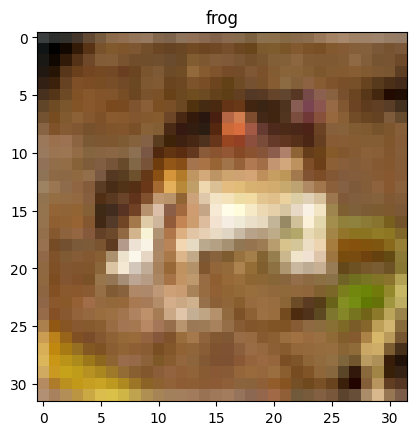

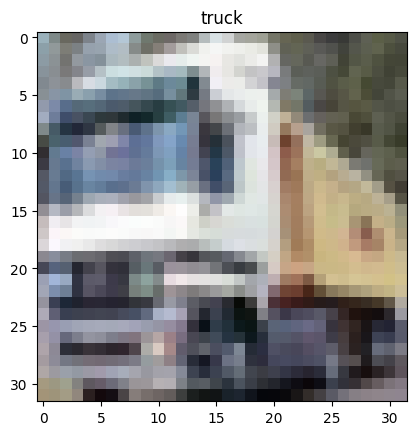

In [167]:
# to get a sense of what we're working with, im printing some images to grasp the data better

for i in range(2):
    img, label = train_dataset[i]
    plt.imshow(img.permute(1, 2, 0))
    plt.title(train_dataset.classes[label])
    plt.show()

In [168]:

log_dir = "runs/cifar10_" + datetime.now().strftime("%Y%m%d-%H%M%S")
writer = SummaryWriter(log_dir)

In [169]:
lr = 0.001
batch_size = 64
epochs = 5

writer.add_text("hyperparameters", f"lr={lr}, batch_size={batch_size}, epochs={epochs}")

In [170]:
writer.add_scalar("test", 1, 0)

In [171]:
# let op, bij gebruiken tensorboard: 
# deze link!

# tensorboard --logdir="C:\Users\D110303\OneDrive - EP Commodities B.V\Bureaublad\Deeplearning_ScriptsMax\College 4 - Hypertuning\runs"

In [172]:
# ok now start really simple with a baseline

class BaselineModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear = nn.Linear(32*32*3, 10)

    def forward(self, x):
        x = self.flatten(x)
        return self.linear(x)

In [173]:
g = torch.Generator()
g.manual_seed(seed)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, generator=g)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [174]:
model = BaselineModel()

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [175]:
def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (preds == labels).sum().item()

    return correct / total

In [176]:
epochs = 5

for epoch in range(epochs):
    model.train()
    running_loss = 0

    for images, labels in train_loader:
        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)

    acc = evaluate(model, test_loader)

    writer.add_scalar("Loss/train", train_loss, epoch)
    writer.add_scalar("Accuracy/test", acc, epoch)

    print(f"Epoch {epoch} - Loss: {train_loss:.4f} - Acc: {acc:.4f}")

Epoch 0 - Loss: 1.9207 - Acc: 0.3597
Epoch 1 - Loss: 1.8423 - Acc: 0.3371
Epoch 2 - Loss: 1.8072 - Acc: 0.3666
Epoch 3 - Loss: 1.7958 - Acc: 0.3349
Epoch 4 - Loss: 1.7856 - Acc: 0.3829


In [177]:
class ImprovedModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)

        self.bn1 = nn.BatchNorm2d(32)
        self.bn2 = nn.BatchNorm2d(64)
        self.bn3 = nn.BatchNorm2d(128)

        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(p=0.1)

        self.flatten = nn.Flatten()
        self.linear1 = nn.Linear(128 * 4 * 4, 128)
        self.linear2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.pool(x)   # 32x32 → 16x16

        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.pool(x)   # 16x16 → 8x8

        x = self.conv3(x)
        x = self.bn3(x)
        x = self.relu(x)
        x = self.pool(x)   # 8x8 → 4x4

        x = self.flatten(x)
        x = self.dropout(x)
        x = self.linear1(x)
        x = self.relu(x)
        return self.linear2(x)

In [179]:
model = ImprovedModel()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
writer = SummaryWriter(log_dir + "_improved")

epochs = 20

for epoch in range(epochs):
    model.train()
    running_loss = 0

    for images, labels in train_loader:
        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    acc = evaluate(model, test_loader)

    writer.add_scalar("Loss/train", train_loss, epoch)
    writer.add_scalar("Accuracy/test", acc, epoch)

    print(f"Epoch {epoch} - Loss: {train_loss:.4f} - Acc: {acc:.4f}")

writer.close()

Epoch 0 - Loss: 1.1904 - Acc: 0.6338
Epoch 1 - Loss: 0.8388 - Acc: 0.6822
Epoch 2 - Loss: 0.7123 - Acc: 0.7173
Epoch 3 - Loss: 0.6227 - Acc: 0.7277
Epoch 4 - Loss: 0.5536 - Acc: 0.7412
Epoch 5 - Loss: 0.4981 - Acc: 0.7386
Epoch 6 - Loss: 0.4490 - Acc: 0.7744
Epoch 7 - Loss: 0.4043 - Acc: 0.7501
Epoch 8 - Loss: 0.3624 - Acc: 0.7266
Epoch 9 - Loss: 0.3275 - Acc: 0.7732
Epoch 10 - Loss: 0.2956 - Acc: 0.7908
Epoch 11 - Loss: 0.2657 - Acc: 0.7748
Epoch 12 - Loss: 0.2418 - Acc: 0.7733
Epoch 13 - Loss: 0.2177 - Acc: 0.7929
Epoch 14 - Loss: 0.2000 - Acc: 0.7836
Epoch 15 - Loss: 0.1803 - Acc: 0.7873
Epoch 16 - Loss: 0.1666 - Acc: 0.7843
Epoch 17 - Loss: 0.1532 - Acc: 0.7829
Epoch 18 - Loss: 0.1448 - Acc: 0.7709
Epoch 19 - Loss: 0.1369 - Acc: 0.7731
